## Sequential Workflow in LangGraph

### 1. Simple Sequential Workflow

In [36]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image, Markdown, display

In [18]:
# define state
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [19]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight']
    height = state['height']

    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state

def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

In [20]:
# define your graph
graph = StateGraph(BMIState)


# add nodes to the graph
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("label_bmi", label_bmi)

# add edges to the graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "label_bmi")
graph.add_edge("label_bmi",  END)

# compile the graph
compiled_graph = graph.compile()

initial_state = {"weight": 70, "height": 1.75}
# execute the graph
output_state = compiled_graph.invoke(initial_state)
print(output_state)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


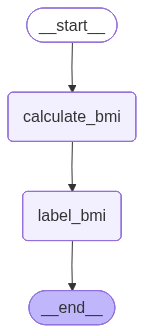

In [21]:
# view the graph
Image(compiled_graph.get_graph().draw_mermaid_png())

### 2. Simple LLM Workflow

In [31]:
from dotenv import load_dotenv
from langgraph.graph  import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [23]:
load_dotenv()

True

In [24]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

In [29]:
output_parser = StrOutputParser()

In [25]:
# create a state class
class LLMState(TypedDict):
    question: str
    answer: str

In [33]:
def llm_qa(state: LLMState) -> LLMState:
    
    question  = state['question']
    
    # form a prompt
    prompt_template = PromptTemplate(
        template="Q: {question}\nA:", 
        input_variables=["question"]
    )
    
    chain = prompt_template|llm|output_parser

    response = chain.invoke({"question": question})
    state['answer'] = response
    return state

In [37]:
# create the graph
graph = StateGraph(LLMState)

# add nodes to the graph
graph.add_node("llm_qa", llm_qa)

# add edges to the graph
graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)

# compile the graph
compiled_graph = graph.compile()

initial_state = {"question": "What is the capital of France?"}

# execute the graph
output_state = compiled_graph.invoke(initial_state)

display(Markdown(output_state['answer']))

The capital of France is Paris.

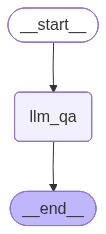

In [38]:
# view the graph
Image(compiled_graph.get_graph().draw_mermaid_png())

### 3. Prompt Chaining Workflow  
```mermaid
graph LR
    A([START]) --> B[gen_outline]
    B --> C[gen_blog]
    C --> D([END])

    style A fill:#4CAF50,color:#fff
    style B fill:#2196F3,color:#fff
    style C fill:#2196F3,color:#fff
    style D fill:#F44336,color:#fff
```

In [39]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image, Markdown, display
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [40]:
load_dotenv()

True

In [41]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

In [43]:
output_parser = StrOutputParser()

In [42]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [48]:
def create_outline(state: BlogState) -> BlogState:
    # fetch title from state
    title = state['title']

    # prompt creation
    prompt_template = PromptTemplate(
        template="Create a detailed outline for a blog post with the title: {title}", 
        input_variables=["title"]
    )

    chain = prompt_template|llm|output_parser

    outline = chain.invoke({"title": title})
    state['outline'] = outline
    return state


def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt_template = PromptTemplate(
        template="Write a blog post with the title: {title} and the following outline: {outline}", 
        input_variables=["title", "outline"]
    )

    chain = prompt_template|llm|output_parser

    content = chain.invoke({"title": title, "outline": outline})
    state['content'] = content
    return state

In [49]:
graph = StateGraph(BlogState)
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)
compiled_graph = graph.compile()

In [50]:
initial_state = {"title": "The Future of AI in Healthcare"}
output_state = compiled_graph.invoke(initial_state)
display(Markdown(output_state['content']))

**The Future of AI in Healthcare**

**Introduction**

Artificial Intelligence (AI) has rapidly become a cornerstone of innovation across various industries, and healthcare is no exception. Currently, AI plays a pivotal role in transforming healthcare systems by enhancing diagnostic accuracy, personalizing treatment plans, and streamlining administrative processes. This blog post aims to explore the future trends and implications of AI in healthcare, highlighting its potential to revolutionize the industry.

**1. Current State of AI in Healthcare**

Today, AI applications in healthcare are diverse and impactful. Diagnostic tools powered by AI can analyze medical images with remarkable precision, often surpassing human capabilities. Personalized medicine is another area where AI shines, using patient data to tailor treatments to individual needs. Additionally, AI is streamlining administrative tasks, reducing the burden on healthcare professionals and allowing them to focus more on patient care.

Success stories abound, with AI improving patient outcomes through early detection of diseases and reducing costs by optimizing resource allocation. For instance, AI algorithms have been instrumental in predicting patient deterioration, enabling timely interventions that save lives and reduce hospital stays.

**2. Emerging AI Technologies in Healthcare**

The future of AI in healthcare is bright, with several emerging technologies poised to make significant impacts. Machine learning and deep learning are advancing rapidly, offering new ways to analyze complex datasets. Natural language processing (NLP) is revolutionizing the way medical records are managed and how patients interact with healthcare systems. Robotics is making strides in surgery and patient care, enhancing precision and reducing recovery times. Furthermore, AI is accelerating drug discovery and development, potentially bringing new treatments to market faster than ever before.

**3. The Potential Benefits of AI in Healthcare**

AI holds the promise of improved diagnostic accuracy and speed, leading to better patient outcomes. It enables enhanced patient care through personalized treatment plans and streamlines operations by reducing the administrative burden on healthcare providers. Predictive analytics powered by AI can aid in disease prevention and management, offering a proactive approach to healthcare that could significantly reduce the incidence of chronic diseases.

**4. Challenges and Ethical Considerations**

Despite its potential, the integration of AI in healthcare is not without challenges. Data privacy and security are paramount concerns, as sensitive patient information must be protected. Bias and fairness in AI algorithms are critical issues that need addressing to ensure equitable healthcare delivery. Transparency and explainability of AI systems are necessary to build trust among healthcare providers and patients. Additionally, regulatory and compliance issues must be navigated carefully to ensure safe and effective AI deployment.

**5. The Role of AI in Global Health**

AI has the potential to address healthcare disparities by improving access to quality care in underserved regions. Telemedicine and remote patient monitoring, powered by AI, can extend healthcare services to remote areas, reducing the gap in healthcare access. By leveraging AI, we can work towards a more equitable global health landscape.

**6. The Future Landscape of AI in Healthcare**

Over the next decade, AI is expected to become deeply integrated into healthcare systems. In the post-pandemic environment, AI will play a crucial role in managing healthcare resources and responding to future health crises. Collaboration between AI developers, healthcare providers, and policymakers will be essential to harness AI's full potential while ensuring ethical standards are upheld.

**7. Preparing for the Future**

To prepare for the future, healthcare professionals must acquire new skills and training to work alongside AI technologies. Investment in AI research and development is crucial to drive innovation. Building robust AI infrastructure within healthcare systems will ensure that these technologies can be effectively implemented and scaled.

**Conclusion**

AI has the transformative potential to revolutionize healthcare, offering unprecedented opportunities to improve patient outcomes and operational efficiency. However, stakeholders must embrace and guide AI development responsibly, balancing innovation with ethical considerations. By doing so, we can ensure that AI becomes a force for good in healthcare.

**References and Further Reading**

- Explore articles, studies, and books on AI in healthcare to deepen your understanding.
- Connect with organizations and initiatives focused on advancing AI in healthcare.

**Call to Action**

We invite you to share your thoughts and experiences with AI in healthcare. Subscribe to our blog for more insights on the intersection of technology and healthcare, and join us in exploring the future of this exciting field.

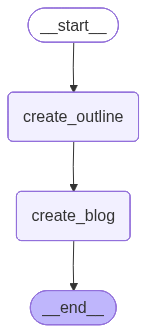

In [51]:
# view the graph
Image(compiled_graph.get_graph().draw_mermaid_png())